# Threshold Tuning Report

Analysis-only report notebook for existing Shopping threshold-tuning runs. It discovers completed `threshold-tuning-*` run artifacts, pools repeated threshold configurations, and writes summary tables plus thesis-oriented figures under `outputs/threshold_tuning_report/`.

## Guardrails

- This notebook reads existing artifacts only.
- It does not launch benchmark runs or create new threshold sweeps.
- First-attempt metrics are exact for `C2-noretry`; for full `C2`, retry-derived decomposition is labeled as a proxy.

In [11]:
from __future__ import annotations

import json
import math
import sys
from collections import Counter
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from analysis.aggregate_benchmark_results import bootstrap_mean_ci, load_benchmark_records


In [12]:
EXPERIMENT_ROOT = REPO_ROOT / "outputs" / "deepplanning" / "experiments"
OUTPUT_ROOT = REPO_ROOT / "outputs" / "threshold_tuning_report"
FIGURE_ROOT = OUTPUT_ROOT / "figures"

INPUT_PATHS: list[Path] = []
THRESHOLD_RUN_GLOBS = (
    "threshold-tuning-*",
)

PRIMARY_SYSTEM = "C2-noretry"
BOOTSTRAP_RESAMPLES = 10_000
BOOTSTRAP_SEED = 20260429

THRESHOLD_POOL_GROUP_COLS = [
    "system",
    "split",
    "loop_similarity_threshold",
    "coverage_threshold",
    "loop_window",
    "loop_repeat_count",
    "final_repair_retry_cap",
]

FIGURE_FILENAMES = {
    "case_accuracy_heatmap": "pooled_case_accuracy_heatmap.png",
    "mean_cost_heatmap": "pooled_mean_cost_heatmap.png",
    "pareto": "threshold_cost_accuracy_pareto.png",
    "per_level": "threshold_per_level_case_accuracy.png",
    "retry": "threshold_retry_decomposition.png",
    "trigger": "threshold_trigger_mix.png",
    "infra": "threshold_infra_failure_heatmap.png",
}


In [13]:
def discover_threshold_run_paths(root: Path = EXPERIMENT_ROOT) -> list[Path]:
    paths: list[Path] = []
    if not root.exists():
        return paths
    for pattern in THRESHOLD_RUN_GLOBS:
        for experiment_dir in sorted(root.glob(pattern)):
            if not experiment_dir.is_dir():
                continue
            session_dirs = [
                path
                for path in sorted(experiment_dir.iterdir())
                if path.is_dir() and (path / "experiment_session.json").exists()
            ]
            paths.extend(session_dirs or [experiment_dir])
    return sorted(dict.fromkeys(paths))


threshold_run_paths = INPUT_PATHS or discover_threshold_run_paths()
print(f"Discovered {len(threshold_run_paths)} threshold-tuning paths")
for path in threshold_run_paths[:12]:
    print(path.relative_to(REPO_ROOT) if path.is_relative_to(REPO_ROOT) else path)


Discovered 13 threshold-tuning paths
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim090-cov040/2026-04-28_00-03-24
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim090-cov050/2026-04-28_00-41-54
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim090-cov060/2026-04-28_01-11-47
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim092-cov040/2026-04-28_01-46-34
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim092-cov050/2026-04-28_02-26-30
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim092-cov060/2026-04-28_06-20-34
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim094-cov040/2026-04-28_09-52-27
outputs/deepplanning/experiments/threshold-tuning-coarse-coarse-primary_noretry-sim094-cov050/2026-04-28_10-34-59
outputs/deepplanning/experiments/threshold-tuning-c

In [14]:
records_df = load_benchmark_records(threshold_run_paths) if threshold_run_paths else pd.DataFrame()
if not records_df.empty:
    records_df = records_df.copy()
    for column in ("loop_similarity_threshold", "coverage_threshold", "loop_window", "loop_repeat_count", "final_repair_retry_cap"):
        if column not in records_df:
            records_df[column] = np.nan
        records_df[column] = pd.to_numeric(records_df[column], errors="coerce")
    records_df = records_df[
        records_df["loop_similarity_threshold"].notna()
        & records_df["coverage_threshold"].notna()
    ].copy()
print(f"Loaded {len(records_df)} threshold-tuning task/eval records")
display(records_df.head())


Loaded 390 threshold-tuning task/eval records


,timestamp,task_id,domain,complexity,system,executor_calls,executor_tokens_in,executor_tokens_out,overseer_calls,overseer_tokens_in,...,overseer_prompt_version,error,eval_case_accuracy,eval_match_score,eval_success,event_trigger_counts,case_accuracy,match_score,task_unit,trigger_counts
0,2026-04-27T22:11:04.817+00:00,10,shopping,None,C2-noretry,33,651473,9983,9,58652,...,c2-lite-v1.4-frozen,NaN,0.0,0.666667,False,"{'final_checkpoint': 1, 'loop_detection': 5, '...",0.0,0.666667,1:10,"{'coverage_deficit': 1, 'final_checkpoint': 3,..."
1,2026-04-27T22:11:13.891+00:00,12,shopping,None,C2-noretry,41,1351429,11745,4,33940,...,c2-lite-v1.4-frozen,NaN,0.0,0.666667,False,"{'final_checkpoint': 1, 'mutating_action': 3}",0.0,0.666667,1:12,"{'coverage_deficit': 1, 'final_checkpoint': 3,..."
2,2026-04-27T22:11:21.454+00:00,13,shopping,None,C2-noretry,32,823525,8586,8,43559,...,c2-lite-v1.4-frozen,NaN,0.0,0.500000,False,"{'final_checkpoint': 1, 'loop_detection': 3, '...",0.0,0.500000,1:13,"{'coverage_deficit': 1, 'final_checkpoint': 3,..."
3,2026-04-27T22:08:29.122+00:00,15,shopping,None,C2-noretry,18,235904,6640,3,10633,...,c2-lite-v1.4-frozen,NaN,0.0,0.666667,False,"{'final_checkpoint': 1, 'mutating_action': 2}",0.0,0.666667,1:15,"{'coverage_deficit': 1, 'final_checkpoint': 3,..."
4,2026-04-27T22:07:14.897+00:00,17,shopping,None,C2-noretry,14,247635,5155,2,8741,...,c2-lite-v1.4-frozen,NaN,0.0,0.666667,False,"{'final_checkpoint': 1, 'mutating_action': 1}",0.0,0.666667,1:17,"{'coverage_deficit': 1, 'final_checkpoint': 3,..."


In [15]:
def json_safe(value: Any) -> Any:
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if not isinstance(value, (dict, list, tuple, str)) and pd.isna(value):
        return None
    return value


def coerce_float(value: Any) -> float | None:
    try:
        result = float(value)
    except (TypeError, ValueError):
        return None
    return None if math.isnan(result) else result


def counter_from_value(value: Any) -> Counter[str]:
    counter: Counter[str] = Counter()
    if isinstance(value, dict):
        for key, count in value.items():
            try:
                counter[str(key)] += int(count or 0)
            except (TypeError, ValueError):
                counter[str(key)] += 1
    elif isinstance(value, list):
        for item in value:
            if isinstance(item, dict):
                trigger = item.get("trigger_type") or item.get("type")
                if trigger:
                    counter[str(trigger)] += 1
            elif item is not None:
                counter[str(item)] += 1
    return counter


def merge_counters(values: Iterable[Any]) -> dict[str, int]:
    counter: Counter[str] = Counter()
    for value in values:
        counter.update(counter_from_value(value))
    return dict(sorted(counter.items()))


def retry_distribution(frame: pd.DataFrame) -> dict[str, int]:
    retry_counts = pd.to_numeric(frame["final_verification_retry_count"], errors="coerce").dropna().astype(int)
    return {str(key): int(value) for key, value in retry_counts.value_counts().sort_index().items()}


def infra_mask(frame: pd.DataFrame) -> pd.Series:
    observation_valid = frame.get("observation_valid", pd.Series(True, index=frame.index))
    invalid = observation_valid.astype(str).str.lower().isin({"false", "0", "no"})
    failure_subtype = frame.get("failure_subtype", pd.Series("", index=frame.index)).astype(str)
    return invalid | failure_subtype.str.contains("infra", case=False, na=False)


def config_id(row: pd.Series | dict[str, Any]) -> str:
    return "sim{:.2f}-cov{:.2f}-{}-retry{}".format(
        float(row["loop_similarity_threshold"]),
        float(row["coverage_threshold"]),
        str(row["system"]),
        int(row["final_repair_retry_cap"]) if pd.notna(row.get("final_repair_retry_cap")) else "na",
    )


In [16]:
def build_threshold_task_frame(records: pd.DataFrame) -> pd.DataFrame:
    if records.empty:
        return pd.DataFrame()
    rows: list[dict[str, Any]] = []
    group_cols = THRESHOLD_POOL_GROUP_COLS + ["level", "task_id"]
    for keys, group in records.groupby(group_cols, dropna=False):
        key_values = dict(zip(group_cols, keys, strict=False))
        case_accuracy = pd.to_numeric(group["case_accuracy"], errors="coerce")
        retry_counts = pd.to_numeric(group["final_verification_retry_count"], errors="coerce")
        retry_known = retry_counts.notna().any()
        if retry_known:
            first_attempt_values = case_accuracy.where(retry_counts.fillna(0).eq(0), 0.0)
            recovered_values = case_accuracy.where(retry_counts.fillna(0).gt(0), 0.0)
        else:
            first_attempt_values = pd.Series(dtype=float)
            recovered_values = pd.Series(dtype=float)
        rows.append(
            {
                **key_values,
                "case_accuracy": case_accuracy.mean(),
                "match_score": pd.to_numeric(group["match_score"], errors="coerce").mean(),
                "total_cost_usd": pd.to_numeric(group["total_cost_usd"], errors="coerce").mean(),
                "overseer_invocation_count": pd.to_numeric(group["overseer_invocation_count"], errors="coerce").mean(),
                "overseer_invoked": pd.to_numeric(group["overseer_invocation_count"], errors="coerce").fillna(0).gt(0).any(),
                "first_attempt_case_accuracy": first_attempt_values.mean() if retry_known else np.nan,
                "recovered_after_retry_accuracy": recovered_values.mean() if retry_known else np.nan,
                "infra_failure": bool(infra_mask(group).any()),
            }
        )
    return pd.DataFrame(rows)


def build_threshold_summary(records: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    task_frame = build_threshold_task_frame(records)
    if records.empty or task_frame.empty:
        return pd.DataFrame(), pd.DataFrame()
    summary_rows: list[dict[str, Any]] = []
    per_level_rows: list[dict[str, Any]] = []
    for keys, group in records.groupby(THRESHOLD_POOL_GROUP_COLS, dropna=False):
        key_values = dict(zip(THRESHOLD_POOL_GROUP_COLS, keys, strict=False))
        task_group = task_frame
        for key, value in key_values.items():
            task_group = task_group[task_group[key].isna()] if pd.isna(value) else task_group[task_group[key].eq(value)]
        case_mean, case_low, case_high = bootstrap_mean_ci(
            task_group["case_accuracy"].tolist(),
            resamples=BOOTSTRAP_RESAMPLES,
            seed=BOOTSTRAP_SEED,
        )
        match_mean, match_low, match_high = bootstrap_mean_ci(
            task_group["match_score"].tolist(),
            resamples=BOOTSTRAP_RESAMPLES,
            seed=BOOTSTRAP_SEED + 1,
        )
        trigger_counts = merge_counters(group["trigger_counts"].tolist())
        trigger_total = sum(trigger_counts.values())
        retry_known = group["final_verification_retry_count"].notna().any()
        no_final_repair_retry = str(key_values["system"]) == "C2-noretry" or float(key_values.get("final_repair_retry_cap") or -1) == 0
        with_retry = coerce_float(task_group["case_accuracy"].mean())
        if no_final_repair_retry:
            first_attempt = with_retry
            recovered = 0.0 if with_retry is not None else None
            retry_added = 0.0 if with_retry is not None else None
            retry_basis = "no_final_repair_retry"
        else:
            first_attempt = coerce_float(task_group["first_attempt_case_accuracy"].mean())
            recovered = coerce_float(task_group["recovered_after_retry_accuracy"].mean())
            retry_added = coerce_float((with_retry or 0.0) - (first_attempt or 0.0)) if retry_known and with_retry is not None and first_attempt is not None else None
            retry_basis = "proxy_from_final_verification_retry_count" if retry_known else "unavailable"
        row = {
            **key_values,
            "config_id": config_id(key_values),
            "task_count": int(task_group[["level", "task_id"]].drop_duplicates().shape[0]),
            "run_count": int(group[["session_root", "run_id"]].drop_duplicates().shape[0]),
            "case_accuracy": case_mean,
            "case_accuracy_ci_low": case_low,
            "case_accuracy_ci_high": case_high,
            "match_score": match_mean,
            "match_score_ci_low": match_low,
            "match_score_ci_high": match_high,
            "mean_total_cost_usd": coerce_float(task_group["total_cost_usd"].mean()),
            "mean_overseer_invocation_count": coerce_float(task_group["overseer_invocation_count"].mean()),
            "overseer_invocation_rate": coerce_float(task_group["overseer_invoked"].mean()),
            "final_verification_retry_distribution": retry_distribution(group),
            "first_attempt_metric_basis": retry_basis,
            "first_attempt_case_accuracy": first_attempt if retry_known or no_final_repair_retry else None,
            "with_retry_case_accuracy": with_retry,
            "retry_added_case_accuracy": retry_added,
            "recovered_after_retry_accuracy": recovered if retry_known or no_final_repair_retry else None,
            "trigger_counts": trigger_counts,
            "trigger_rates": {key: value / trigger_total if trigger_total else 0.0 for key, value in trigger_counts.items()},
            "infra_failure_count": int(infra_mask(group).sum()),
            "infra_failure_rate": coerce_float(infra_mask(group).mean()),
            "contributing_experiment_count": int(group["experiment_name"].nunique()),
            "contributing_experiments": sorted(str(value) for value in group["experiment_name"].dropna().unique()),
            "contributing_session_count": int(group["session_root"].nunique()),
            "contributing_sessions": sorted(str(value) for value in group["session_root"].dropna().unique()),
        }
        summary_rows.append(row)
    for keys, group in task_frame.groupby(THRESHOLD_POOL_GROUP_COLS + ["level"], dropna=False):
        key_values = dict(zip(THRESHOLD_POOL_GROUP_COLS + ["level"], keys, strict=False))
        per_level_rows.append(
            {
                **key_values,
                "config_id": config_id(key_values),
                "level_label": f"L{int(key_values['level'])}" if pd.notna(key_values["level"]) else "unknown",
                "task_count": int(len(group)),
                "case_accuracy": coerce_float(group["case_accuracy"].mean()),
                "match_score": coerce_float(group["match_score"].mean()),
                "infra_failure_count": int(group["infra_failure"].sum()),
                "infra_failure_rate": coerce_float(group["infra_failure"].mean()),
            }
        )
    summary_df = pd.DataFrame(summary_rows).sort_values(["system", "loop_similarity_threshold", "coverage_threshold"], kind="stable")
    per_level_df = pd.DataFrame(per_level_rows).sort_values(["system", "loop_similarity_threshold", "coverage_threshold", "level_label"], kind="stable")
    return summary_df, per_level_df


summary_df, per_level_df = build_threshold_summary(records_df)
display(summary_df)
display(per_level_df.head())


,system,split,loop_similarity_threshold,coverage_threshold,loop_window,loop_repeat_count,final_repair_retry_cap,config_id,task_count,run_count,...,retry_added_case_accuracy,recovered_after_retry_accuracy,trigger_counts,trigger_rates,infra_failure_count,infra_failure_rate,contributing_experiment_count,contributing_experiments,contributing_session_count,contributing_sessions
0,C2-noretry,tune,0.90,0.4,5,3,0,sim0.90-cov0.40-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 30, 'error_occurrence': 1...","{'coverage_deficit': 0.07142857142857142, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
1,C2-noretry,tune,0.90,0.5,5,3,0,sim0.90-cov0.50-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 29, 'error_occurrence': 1...","{'coverage_deficit': 0.06937799043062201, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
2,C2-noretry,tune,0.90,0.6,5,3,0,sim0.90-cov0.60-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 54, 'error_occurrence': 2...","{'coverage_deficit': 0.075, 'error_occurrence'...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
3,C2-noretry,tune,0.92,0.4,5,3,0,sim0.92-cov0.40-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 27, 'error_occurrence': 6...","{'coverage_deficit': 0.0782608695652174, 'erro...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
4,C2-noretry,tune,0.92,0.5,5,3,0,sim0.92-cov0.50-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 28, 'error_occurrence': 1...","{'coverage_deficit': 0.07588075880758807, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
5,C2-noretry,tune,0.92,0.6,5,3,0,sim0.92-cov0.60-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 59, 'error_occurrence': 4...","{'coverage_deficit': 0.06965761511216056, 'err...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
6,C2-noretry,tune,0.94,0.4,5,3,0,sim0.94-cov0.40-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 57, 'error_occurrence': 3...","{'coverage_deficit': 0.07224334600760456, 'err...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
7,C2-noretry,tune,0.94,0.5,5,3,0,sim0.94-cov0.50-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 28, 'error_occurrence': 1...","{'coverage_deficit': 0.06349206349206349, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
8,C2-noretry,tune,0.94,0.6,5,3,0,sim0.94-cov0.60-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 58, 'error_occurrence': 3...","{'coverage_deficit': 0.06880189798339265, 'err...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...


,system,split,loop_similarity_threshold,coverage_threshold,loop_window,loop_repeat_count,final_repair_retry_cap,level,config_id,level_label,task_count,case_accuracy,match_score,infra_failure_count,infra_failure_rate
0,C2-noretry,tune,0.9,0.4,5,3,0,1,sim0.90-cov0.40-C2-noretry-retry0,L1,13,0.384615,0.755128,0,0.0
1,C2-noretry,tune,0.9,0.4,5,3,0,2,sim0.90-cov0.40-C2-noretry-retry0,L2,12,0.250000,0.562500,0,0.0
2,C2-noretry,tune,0.9,0.4,5,3,0,3,sim0.90-cov0.40-C2-noretry-retry0,L3,5,0.400000,0.803333,0,0.0
3,C2-noretry,tune,0.9,0.5,5,3,0,1,sim0.90-cov0.50-C2-noretry-retry0,L1,13,0.384615,0.684615,0,0.0
4,C2-noretry,tune,0.9,0.5,5,3,0,2,sim0.90-cov0.50-C2-noretry-retry0,L2,12,0.250000,0.619444,0,0.0


In [17]:
def pareto_frontier_configs(summary: pd.DataFrame) -> set[str]:
    candidates = summary.dropna(subset=["case_accuracy", "mean_total_cost_usd"])
    frontier: set[str] = set()
    for _, row in candidates.iterrows():
        accuracy = float(row["case_accuracy"])
        cost = float(row["mean_total_cost_usd"])
        dominated = False
        for _, other in candidates.iterrows():
            if row["config_id"] == other["config_id"]:
                continue
            other_accuracy = float(other["case_accuracy"])
            other_cost = float(other["mean_total_cost_usd"])
            if other_accuracy >= accuracy and other_cost <= cost and (other_accuracy > accuracy or other_cost < cost):
                dominated = True
                break
        if not dominated:
            frontier.add(str(row["config_id"]))
    return frontier


ranked_df = summary_df.sort_values(
    ["case_accuracy", "match_score", "mean_total_cost_usd"],
    ascending=[False, False, True],
    kind="stable",
) if not summary_df.empty else pd.DataFrame()
display(ranked_df.head(12))


,system,split,loop_similarity_threshold,coverage_threshold,loop_window,loop_repeat_count,final_repair_retry_cap,config_id,task_count,run_count,...,retry_added_case_accuracy,recovered_after_retry_accuracy,trigger_counts,trigger_rates,infra_failure_count,infra_failure_rate,contributing_experiment_count,contributing_experiments,contributing_session_count,contributing_sessions
6,C2-noretry,tune,0.94,0.4,5,3,0,sim0.94-cov0.40-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 57, 'error_occurrence': 3...","{'coverage_deficit': 0.07224334600760456, 'err...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
8,C2-noretry,tune,0.94,0.6,5,3,0,sim0.94-cov0.60-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 58, 'error_occurrence': 3...","{'coverage_deficit': 0.06880189798339265, 'err...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
0,C2-noretry,tune,0.90,0.4,5,3,0,sim0.90-cov0.40-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 30, 'error_occurrence': 1...","{'coverage_deficit': 0.07142857142857142, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
5,C2-noretry,tune,0.92,0.6,5,3,0,sim0.92-cov0.60-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 59, 'error_occurrence': 4...","{'coverage_deficit': 0.06965761511216056, 'err...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
1,C2-noretry,tune,0.90,0.5,5,3,0,sim0.90-cov0.50-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 29, 'error_occurrence': 1...","{'coverage_deficit': 0.06937799043062201, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
7,C2-noretry,tune,0.94,0.5,5,3,0,sim0.94-cov0.50-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 28, 'error_occurrence': 1...","{'coverage_deficit': 0.06349206349206349, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
3,C2-noretry,tune,0.92,0.4,5,3,0,sim0.92-cov0.40-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 27, 'error_occurrence': 6...","{'coverage_deficit': 0.0782608695652174, 'erro...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...
2,C2-noretry,tune,0.90,0.6,5,3,0,sim0.90-cov0.60-C2-noretry-retry0,30,2,...,0.0,0.0,"{'coverage_deficit': 54, 'error_occurrence': 2...","{'coverage_deficit': 0.075, 'error_occurrence'...",0,0.0,2,[threshold-tuning-coarse-coarse-primary_noretr...,2,[/Users/dntgafck/msai/thesis/deepplanning-sele...
4,C2-noretry,tune,0.92,0.5,5,3,0,sim0.92-cov0.50-C2-noretry-retry0,30,1,...,0.0,0.0,"{'coverage_deficit': 28, 'error_occurrence': 1...","{'coverage_deficit': 0.07588075880758807, 'err...",0,0.0,1,[threshold-tuning-coarse-coarse-primary_noretr...,1,[/Users/dntgafck/msai/thesis/deepplanning-sele...


In [18]:
def save_empty(path: Path, title: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.axis("off")
    ax.text(0.5, 0.5, "No data", ha="center", va="center")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def plot_threshold_heatmap(summary: pd.DataFrame, value_col: str, title: str, path: Path, *, system: str = PRIMARY_SYSTEM) -> None:
    rows = summary[summary["system"].eq(system)].copy() if not summary.empty else pd.DataFrame()
    if rows.empty or value_col not in rows:
        save_empty(path, title)
        return
    pivot = rows.pivot_table(index="coverage_threshold", columns="loop_similarity_threshold", values=value_col, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    image = ax.imshow(pivot.values, aspect="auto", origin="lower")
    ax.set_xticks(range(len(pivot.columns)), [f"{value:.2f}" for value in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), [f"{value:.2f}" for value in pivot.index])
    ax.set_xlabel("loop_similarity_threshold")
    ax.set_ylabel("coverage_threshold")
    ax.set_title(title)
    for y, cov in enumerate(pivot.index):
        for x, sim in enumerate(pivot.columns):
            value = pivot.loc[cov, sim]
            label = "NA" if pd.isna(value) else f"{value:.3f}"
            ax.text(x, y, label, ha="center", va="center", color="white")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def plot_threshold_pareto(summary: pd.DataFrame, path: Path, *, system: str = PRIMARY_SYSTEM) -> None:
    rows = summary[summary["system"].eq(system)].dropna(subset=["case_accuracy", "mean_total_cost_usd"]).copy() if not summary.empty else pd.DataFrame()
    if rows.empty:
        save_empty(path, "Threshold Cost vs Accuracy")
        return
    frontier = pareto_frontier_configs(rows)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for _, row in rows.iterrows():
        is_frontier = row["config_id"] in frontier
        ax.scatter(float(row["mean_total_cost_usd"]), float(row["case_accuracy"]), marker="D" if is_frontier else "o", s=90 if is_frontier else 55)
        ax.annotate(f"{row['loop_similarity_threshold']:.2f}/{row['coverage_threshold']:.2f}", (float(row["mean_total_cost_usd"]), float(row["case_accuracy"])), xytext=(5, 5), textcoords="offset points")
    frontier_rows = rows[rows["config_id"].isin(frontier)].sort_values("mean_total_cost_usd")
    if len(frontier_rows) > 1:
        ax.plot(frontier_rows["mean_total_cost_usd"], frontier_rows["case_accuracy"], linewidth=1, alpha=0.7)
    ax.set_xlabel("Mean cost/task (USD)")
    ax.set_ylabel("Case Accuracy")
    ax.set_ylim(0, 1)
    ax.set_title(f"{system} Threshold Cost vs Accuracy")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def plot_threshold_per_level(per_level: pd.DataFrame, path: Path, *, top_n: int = 6) -> None:
    if per_level.empty:
        save_empty(path, "Threshold Per-level Accuracy")
        return
    top_configs = ranked_df["config_id"].head(top_n).tolist() if not ranked_df.empty else per_level["config_id"].drop_duplicates().head(top_n).tolist()
    rows = per_level[per_level["config_id"].isin(top_configs)]
    labels = top_configs
    levels = sorted(rows["level_label"].dropna().unique())
    x = np.arange(len(levels))
    width = 0.8 / max(len(labels), 1)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for index, label in enumerate(labels):
        values = []
        for level in levels:
            subset = rows[rows["config_id"].eq(label) & rows["level_label"].eq(level)]
            values.append(float(subset["case_accuracy"].iloc[0]) if not subset.empty and pd.notna(subset["case_accuracy"].iloc[0]) else 0.0)
        ax.bar(x + (index - (len(labels) - 1) / 2) * width, values, width, label=label)
    ax.set_xticks(x, levels)
    ax.set_ylabel("Case Accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Case Accuracy by Shopping Level and Threshold Config")
    ax.legend(fontsize="x-small")
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


### Case Accuracy Heatmap

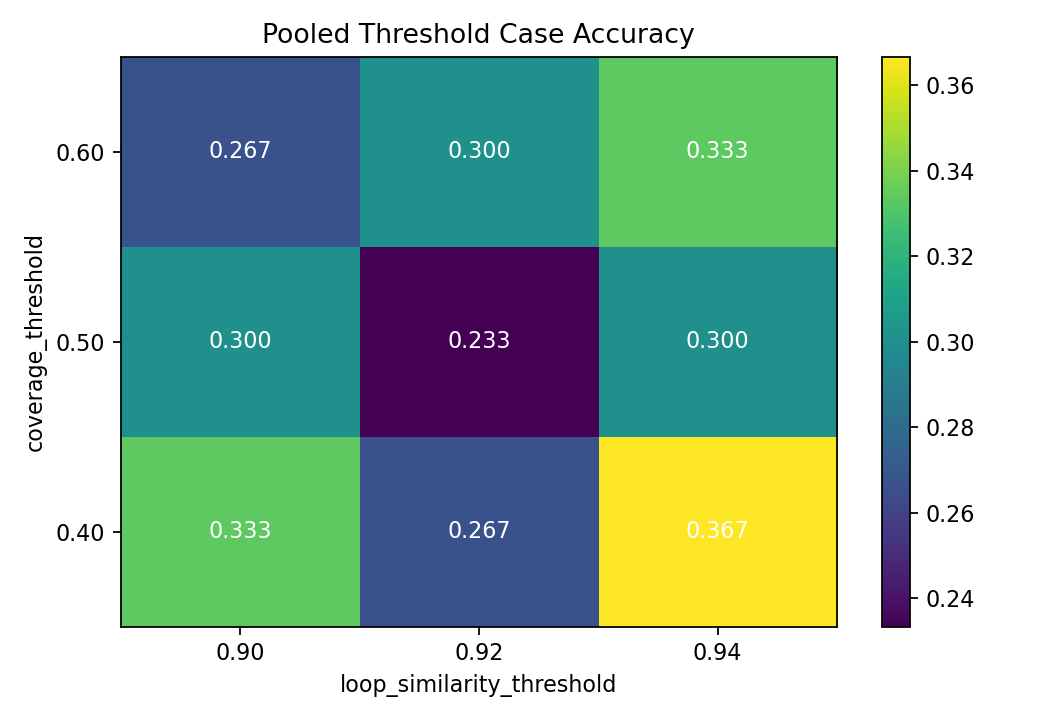

### Mean Cost Heatmap

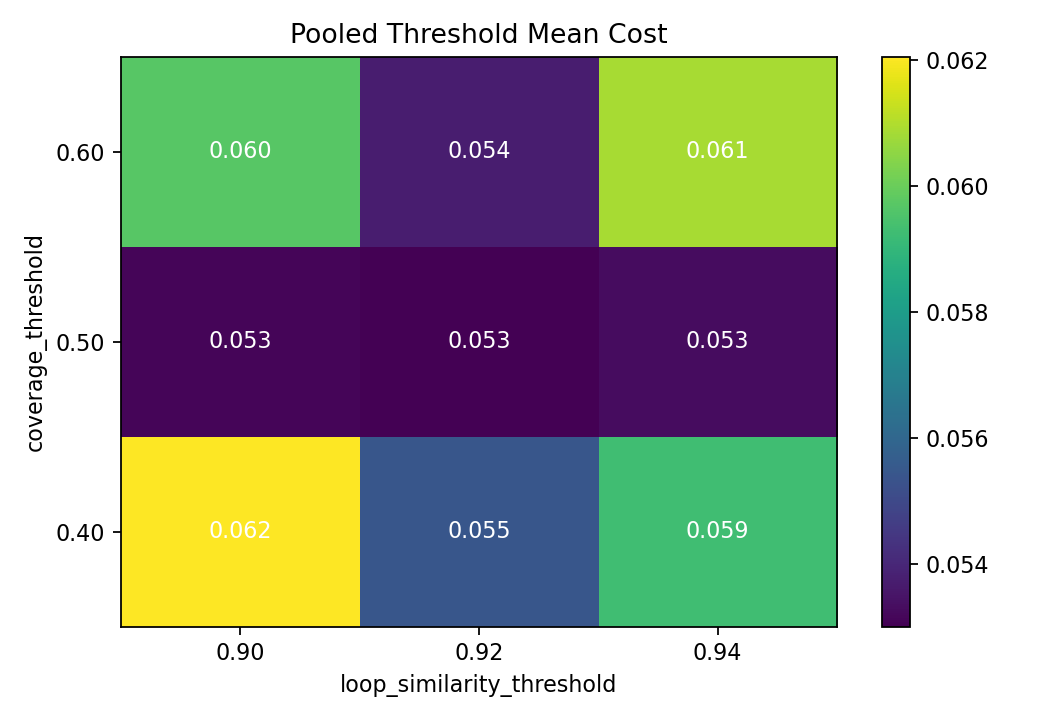

### Pareto

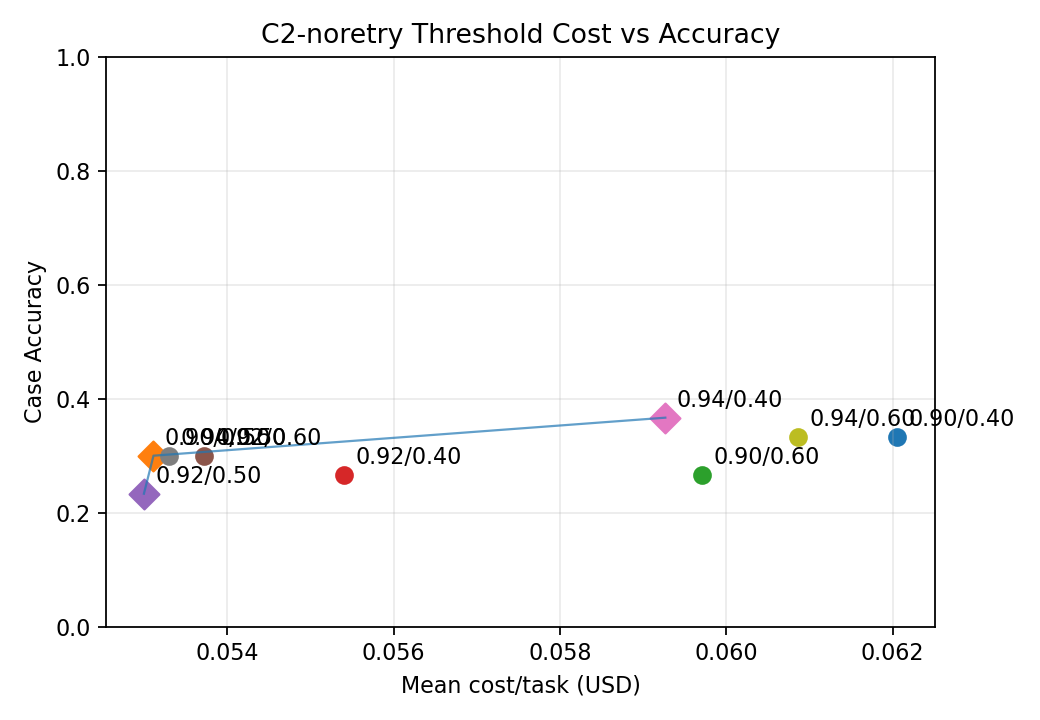

### Per Level

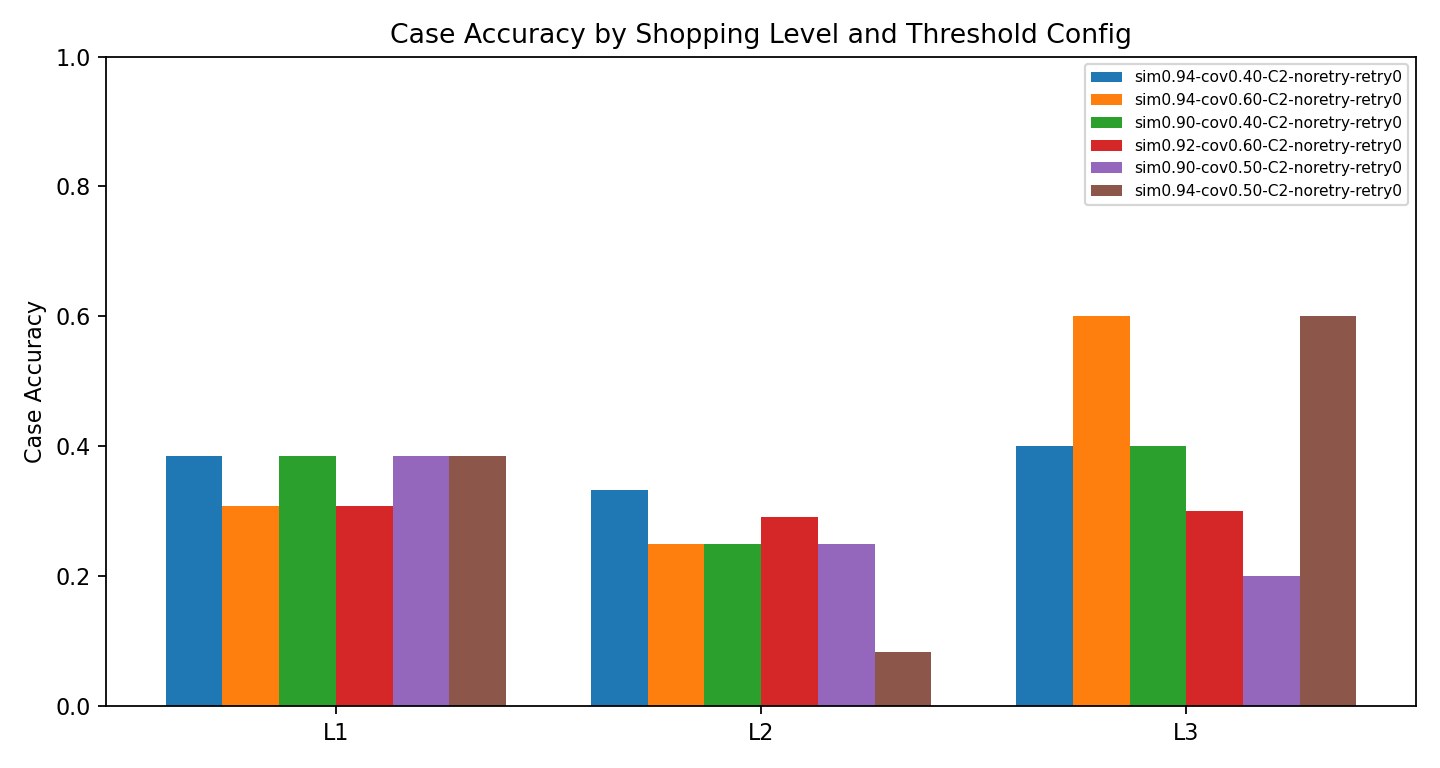

### Retry

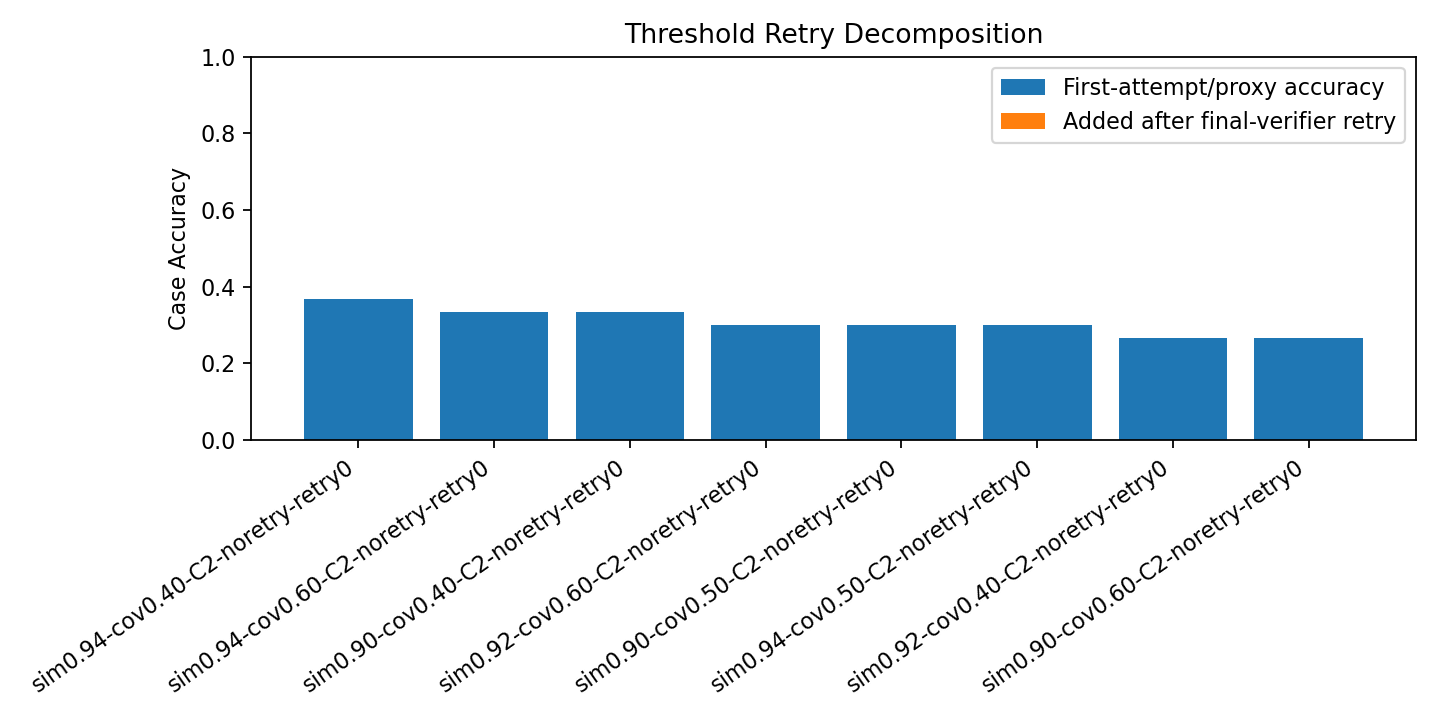

### Trigger

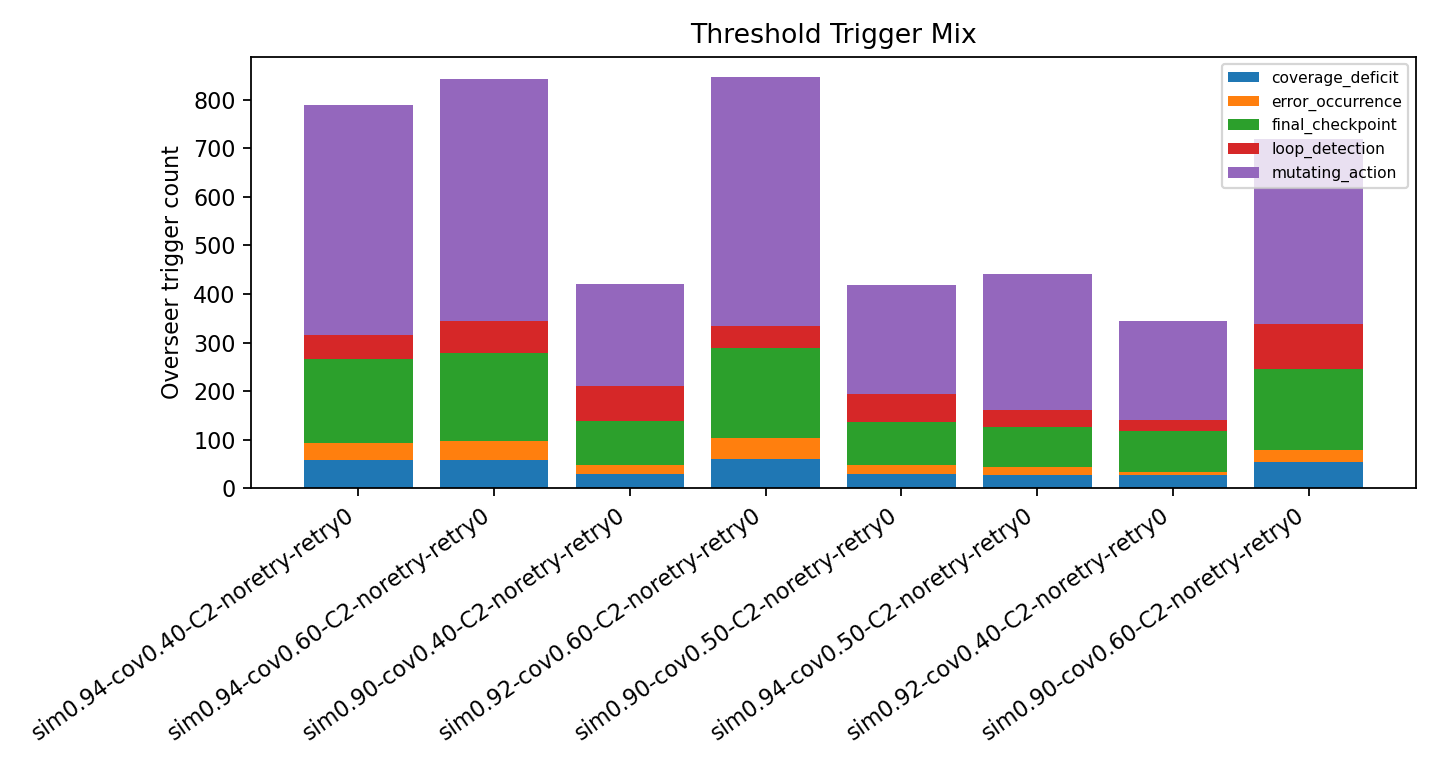

### Infra

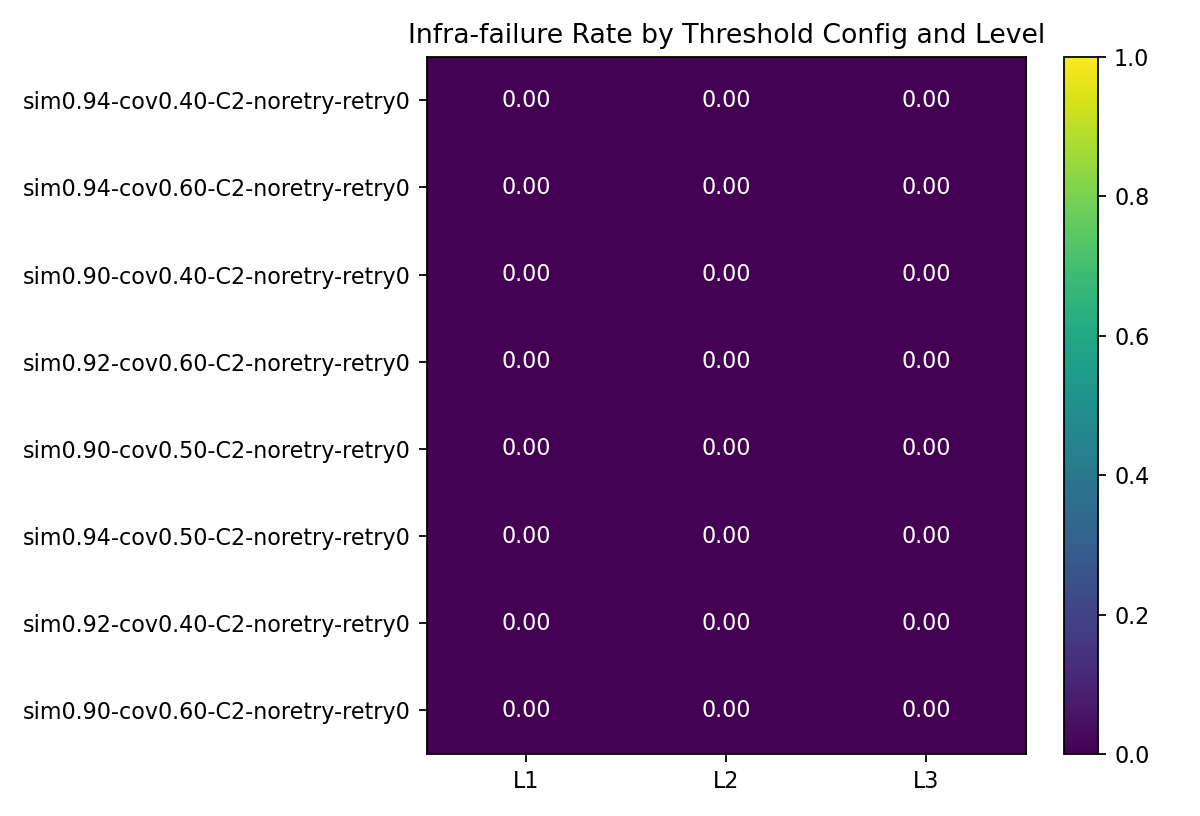

{'case_accuracy_heatmap': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/pooled_case_accuracy_heatmap.png'),
 'mean_cost_heatmap': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/pooled_mean_cost_heatmap.png'),
 'pareto': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/threshold_cost_accuracy_pareto.png'),
 'per_level': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/threshold_per_level_case_accuracy.png'),
 'retry': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/threshold_retry_decomposition.png'),
 'trigger': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/threshold_trigger_mix.png'),
 'infra': PosixPath(

In [19]:
def plot_threshold_retry(summary: pd.DataFrame, path: Path, *, top_n: int = 8) -> None:
    rows = summary.dropna(subset=["first_attempt_case_accuracy", "with_retry_case_accuracy"]).head(top_n) if not summary.empty else pd.DataFrame()
    if rows.empty:
        save_empty(path, "Threshold Retry Decomposition")
        return
    labels = rows["config_id"].tolist()
    first = rows["first_attempt_case_accuracy"].astype(float).to_numpy()
    added = rows["retry_added_case_accuracy"].fillna(0).astype(float).to_numpy()
    x = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x, first, label="First-attempt/proxy accuracy")
    ax.bar(x, added, bottom=first, label="Added after final-verifier retry")
    ax.set_xticks(x, labels, rotation=35, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Case Accuracy")
    ax.set_title("Threshold Retry Decomposition")
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def plot_threshold_trigger_mix(summary: pd.DataFrame, path: Path, *, top_n: int = 8) -> None:
    rows = summary.head(top_n) if not summary.empty else pd.DataFrame()
    trigger_names = sorted({trigger for counts in rows.get("trigger_counts", []) for trigger in counts})
    if rows.empty or not trigger_names:
        save_empty(path, "Threshold Trigger Mix")
        return
    x = np.arange(len(rows))
    bottoms = np.zeros(len(rows))
    fig, ax = plt.subplots(figsize=(9, 4.8))
    for trigger in trigger_names:
        values = np.array([float(counts.get(trigger, 0)) for counts in rows["trigger_counts"]])
        ax.bar(x, values, bottom=bottoms, label=trigger)
        bottoms += values
    ax.set_xticks(x, rows["config_id"].tolist(), rotation=35, ha="right")
    ax.set_ylabel("Overseer trigger count")
    ax.set_title("Threshold Trigger Mix")
    ax.legend(fontsize="x-small")
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def plot_threshold_infra_heatmap(per_level: pd.DataFrame, path: Path, *, top_n: int = 8) -> None:
    if per_level.empty:
        save_empty(path, "Threshold Infra-failure Heatmap")
        return
    top_configs = ranked_df["config_id"].head(top_n).tolist() if not ranked_df.empty else per_level["config_id"].drop_duplicates().head(top_n).tolist()
    rows = per_level[per_level["config_id"].isin(top_configs)]
    pivot = rows.pivot_table(index="config_id", columns="level_label", values="infra_failure_rate", aggfunc="mean").reindex(top_configs)
    fig, ax = plt.subplots(figsize=(7.5, max(3, 0.45 * len(pivot.index) + 1.5)))
    image = ax.imshow(pivot.fillna(0).values, vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), list(pivot.columns))
    ax.set_yticks(range(len(pivot.index)), list(pivot.index))
    ax.set_title("Infra-failure Rate by Threshold Config and Level")
    for y, config in enumerate(pivot.index):
        for x, level in enumerate(pivot.columns):
            value = pivot.loc[config, level]
            ax.text(x, y, "NA" if pd.isna(value) else f"{value:.2f}", ha="center", va="center", color="white")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def write_threshold_figures(summary: pd.DataFrame, per_level: pd.DataFrame) -> dict[str, Path]:
    FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
    paths = {name: FIGURE_ROOT / filename for name, filename in FIGURE_FILENAMES.items()}
    plot_threshold_heatmap(summary, "case_accuracy", "Pooled Threshold Case Accuracy", paths["case_accuracy_heatmap"])
    plot_threshold_heatmap(summary, "mean_total_cost_usd", "Pooled Threshold Mean Cost", paths["mean_cost_heatmap"])
    plot_threshold_pareto(summary, paths["pareto"])
    plot_threshold_per_level(per_level, paths["per_level"])
    plot_threshold_retry(ranked_df if not ranked_df.empty else summary, paths["retry"])
    plot_threshold_trigger_mix(ranked_df if not ranked_df.empty else summary, paths["trigger"])
    plot_threshold_infra_heatmap(per_level, paths["infra"])
    return paths


figure_paths = write_threshold_figures(summary_df, per_level_df)
for figure_name, figure_path in figure_paths.items():
    display(Markdown(f"### {figure_name.replace('_', ' ').title()}"))
    display(Image(filename=str(figure_path)))
figure_paths


In [20]:
def write_markdown_report(summary: pd.DataFrame, per_level: pd.DataFrame, figure_paths: dict[str, Path]) -> Path:
    report_path = OUTPUT_ROOT / "report.md"
    lines = [
        "# Threshold Tuning Report",
        "",
        f"Source paths: `{len(threshold_run_paths)}`",
        f"Bootstrap resamples: `{BOOTSTRAP_RESAMPLES}`",
        f"Bootstrap seed: `{BOOTSTRAP_SEED}`",
        "",
        "First-attempt decomposition is exact for `C2-noretry`; for full `C2`, it uses a proxy derived from `final_verification_retry_count` when available.",
        "",
        "## Top Configurations",
        "",
    ]
    if summary.empty:
        lines.append("No threshold-tuning records were found.")
    else:
        lines.extend([
            "| Config | System | Split | Tasks | Runs | Case Accuracy | 95% CI | Match Score | Mean Cost | Overseer Rate | Infra Rate |",
            "| --- | --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |",
        ])
        for _, row in ranked_df.head(15).iterrows():
            ci = "NA" if pd.isna(row["case_accuracy_ci_low"]) else f"{row['case_accuracy_ci_low']:.3f}-{row['case_accuracy_ci_high']:.3f}"
            lines.append(
                f"| {row['config_id']} | {row['system']} | {row['split']} | {int(row['task_count'])} | {int(row['run_count'])} | {row['case_accuracy']:.3f} | {ci} | {row['match_score']:.3f} | {row['mean_total_cost_usd']:.4f} | {row['overseer_invocation_rate']:.3f} | {row['infra_failure_rate']:.3f} |"
            )
    lines.extend(["", "## Figures", ""])
    for name, path in figure_paths.items():
        lines.append(f"- `{name}`: `{path.relative_to(REPO_ROOT) if path.is_relative_to(REPO_ROOT) else path}`")
    lines.extend(["", "## Per-level Output", "", "See `per_level.csv` for per-level rows."])
    report_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return report_path


def write_threshold_report_outputs(summary: pd.DataFrame, per_level: pd.DataFrame, figure_paths: dict[str, Path]) -> dict[str, Path]:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    summary_csv = OUTPUT_ROOT / "summary.csv"
    summary_json = OUTPUT_ROOT / "summary.json"
    per_level_csv = OUTPUT_ROOT / "per_level.csv"
    report_md = write_markdown_report(summary, per_level, figure_paths)
    csv_summary = summary.copy()
    for column in ("final_verification_retry_distribution", "trigger_counts", "trigger_rates", "contributing_experiments", "contributing_sessions"):
        if column in csv_summary:
            csv_summary[column] = csv_summary[column].map(lambda value: json.dumps(json_safe(value), sort_keys=True))
    csv_summary.to_csv(summary_csv, index=False)
    per_level.to_csv(per_level_csv, index=False)
    summary_json.write_text(
        json.dumps(
            {
                "bootstrap": {"resamples": BOOTSTRAP_RESAMPLES, "seed": BOOTSTRAP_SEED, "unit": "shopping task"},
                "source_paths": [str(path) for path in threshold_run_paths],
                "pooling_keys": THRESHOLD_POOL_GROUP_COLS,
                "summary": json_safe(summary.to_dict(orient="records")),
                "per_level": json_safe(per_level.to_dict(orient="records")),
                "figures": {key: str(path) for key, path in figure_paths.items()},
            },
            indent=2,
            sort_keys=True,
        ) + "\n",
        encoding="utf-8",
    )
    return {"summary_csv": summary_csv, "summary_json": summary_json, "per_level_csv": per_level_csv, "report_md": report_md, **figure_paths}


output_paths = write_threshold_report_outputs(summary_df, per_level_df, figure_paths)
output_paths


{'summary_csv': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/summary.csv'),
 'summary_json': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/summary.json'),
 'per_level_csv': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/per_level.csv'),
 'report_md': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/report.md'),
 'case_accuracy_heatmap': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/pooled_case_accuracy_heatmap.png'),
 'mean_cost_heatmap': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/figures/pooled_mean_cost_heatmap.png'),
 'pareto': PosixPath('/Users/dntgafck/msai/thesis/deepplanning-selective-oversight/outputs/threshold_tuning_report/fig